I052

Reya Oberoi

ATML Lab7 Image Captioning

#  Image Captioning - Encoder-Decoder With Bahdanau Attention
**Dataset**: Flickr8k from Kaggle

**Architecture**: Custom CNN Encoder + Attention + LSTM Decoder

## 1. Setup & Kaggle Authentication

In [1]:
!pip install kaggle --quiet

In [2]:
import os
from google.colab import files

print('Upload your kaggle.json file:')
uploaded = files.upload()

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('Kaggle API configured!')

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle API configured!


## 2. Download Flickr8k Dataset

In [3]:
!kaggle datasets download -d adityajn105/flickr8k --unzip -p /content/flickr8k
!ls /content/flickr8k/

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:05<00:00, 200MB/s]

captions.txt  Images


## 3. Imports

In [4]:
import os, re, json, random, math
import numpy as np
import pandas as pd
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

Using device: cuda


## 4. Hyperparameters

In [5]:

DATASET_SIZE    = 6000
BATCH_SIZE      = 32
NUM_EPOCHS      = 15
LEARNING_RATE   = 3e-4
EMBED_DIM       = 256
HIDDEN_DIM      = 512
NUM_LAYERS      = 1
IMG_SIZE        = 224
MAX_SEQ_LEN     = 35
VOCAB_THRESHOLD = 3
TRAIN_RATIO     = 0.80
VAL_RATIO       = 0.10

# ── Attention-specific ──
ATTENTION_DIM   = 256    # size of attention hidden layer
ENC_FEAT_DIM    = 512    # CNN last stage channels
NUM_PIXELS      = 7 * 7  # spatial locations from CNN (7x7 feature map)

IMG_DIR  = '/content/flickr8k/Images'
CAP_FILE = '/content/flickr8k/captions.txt'

print('Hyperparameters set.')

Hyperparameters set.


## 5. Vocabulary & Caption Preprocessing

In [6]:
def clean_text(caption):
    caption = caption.lower()
    caption = re.sub(r"[^a-z0-9\s]", "", caption)
    caption = re.sub(r"\s+", " ", caption).strip()
    return caption


class Vocabulary:
    def __init__(self, freq_threshold=3):
        self.freq_threshold = freq_threshold
        self.word2idx = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self.freq = Counter()

    def build(self, captions):
        for cap in captions:
            for word in cap.split():
                self.freq[word] += 1
        idx = len(self.word2idx)
        for word, cnt in self.freq.items():
            if cnt >= self.freq_threshold:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1
        print(f'Vocabulary size: {len(self.word2idx)}')

    def encode(self, caption):
        return [self.word2idx.get(w, self.word2idx['<UNK>']) for w in caption.split()]

    def decode(self, indices):
        words = []
        for i in indices:
            word = self.idx2word.get(i, '<UNK>')
            if word in ('<EOS>', '<PAD>'):
                break
            if word not in ('<SOS>',):
                words.append(word)
        return ' '.join(words)

    def __len__(self):
        return len(self.word2idx)


df = pd.read_csv(CAP_FILE)
df.columns = df.columns.str.strip()
df.columns = ['image', 'caption']
df['caption'] = df['caption'].apply(clean_text)
df['exists']  = df['image'].apply(lambda x: os.path.exists(os.path.join(IMG_DIR, x)))
df = df[df['exists']].drop(columns=['exists'])

unique_images = df['image'].unique()[:DATASET_SIZE]
df = df[df['image'].isin(unique_images)].reset_index(drop=True)

n = len(unique_images)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
np.random.shuffle(unique_images)
train_imgs = set(unique_images[:n_train])
val_imgs   = set(unique_images[n_train:n_train+n_val])
test_imgs  = set(unique_images[n_train+n_val:])

train_df = df[df['image'].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df['image'].isin(val_imgs)].reset_index(drop=True)
test_df  = df[df['image'].isin(test_imgs)].reset_index(drop=True)
print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

vocab = Vocabulary(freq_threshold=VOCAB_THRESHOLD)
vocab.build(train_df['caption'].tolist())
VOCAB_SIZE = len(vocab)

Train: 24000  Val: 3000  Test: 3000
Vocabulary size: 3151


## 6. Dataset - Returns Spatial Features

In [7]:
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])


class Flickr8kDataset(Dataset):
    def __init__(self, dataframe, img_dir, vocab, transform, max_len=MAX_SEQ_LEN):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.vocab = vocab
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row['image'])).convert('RGB')
        img = self.transform(img)
        tokens = ([self.vocab.word2idx['<SOS>']] +
                  self.vocab.encode(row['caption']) +
                  [self.vocab.word2idx['<EOS>']])
        tokens = tokens[:self.max_len]
        pad_len = self.max_len - len(tokens)
        tokens = tokens + [self.vocab.word2idx['<PAD>']] * pad_len
        return img, torch.tensor(tokens, dtype=torch.long)


train_dataset = Flickr8kDataset(train_df, IMG_DIR, vocab, transform_train)
val_dataset   = Flickr8kDataset(val_df,   IMG_DIR, vocab, transform_val)
test_dataset  = Flickr8kDataset(test_df,  IMG_DIR, vocab, transform_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

Train batches: 750  Val: 94  Test: 94


## 7. Model Architecture — CNN Encoder + Bahdanau Attention + LSTM Decoder

In [20]:
#  Residual ConvBlock
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.skip = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch),
        ) if in_ch != out_ch or stride != 1 else nn.Identity()

    def forward(self, x):
        return F.relu(self.block(x) + self.skip(x))


#  CNN Encoder — outputs SPATIAL feature map
#  (B, 512, 7, 7)  →  (B, 49, 512) for attention

class CNNEncoder(nn.Module):
    def __init__(self,):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )
        self.layer1 = ConvBlock(32,  64)
        self.layer2 = ConvBlock(64,  128, stride=2)
        self.layer3 = ConvBlock(128, 256, stride=2)
        self.layer4 = ConvBlock(256, 512, stride=2)
        # Project channels to HIDDEN_DIM for attention
        self.proj = nn.Conv2d(512, HIDDEN_DIM, 1)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)            # (B, 512, 7, 7)
        x = self.proj(x)              # (B, H, 7, 7)
        B, C, H, W = x.shape
        x = x.permute(0, 2, 3, 1).reshape(B, H*W, C)  # (B, 49, H)
        return x


#  Bahdanau (Additive) Attention
class BahdanauAttention(nn.Module):
    """
    e_t = v^T tanh(W1 * enc + W2 * h_t)
    alpha_t = softmax(e_t)
    context_t = sum(alpha * enc)
    """
    def __init__(self, enc_dim, dec_dim, attn_dim):
        super().__init__()
        self.W_enc = nn.Linear(enc_dim, attn_dim, bias=False)
        self.W_dec = nn.Linear(dec_dim, attn_dim, bias=False)
        self.v      = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, enc_out, h):
        """
        enc_out : (B, num_pixels, enc_dim)
        h       : (B, dec_dim)
        returns context (B, enc_dim), alpha (B, num_pixels)
        """
        enc_proj = self.W_enc(enc_out)                          # (B, P, A)
        dec_proj = self.W_dec(h).unsqueeze(1)                   # (B, 1, A)
        energy   = self.v(torch.tanh(enc_proj + dec_proj))      # (B, P, 1)
        alpha    = F.softmax(energy.squeeze(-1), dim=-1)        # (B, P)
        context  = (alpha.unsqueeze(-1) * enc_out).sum(dim=1)  # (B, enc_dim)
        return context, alpha


#  Attention Decoder
class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, enc_dim, attn_dim):
        super().__init__()
        self.embed     = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = BahdanauAttention(enc_dim, hidden_dim, attn_dim)
        # LSTM input = word_embed + context vector
        self.lstm_cell = nn.LSTMCell(embed_dim + enc_dim, hidden_dim)
        self.dropout   = nn.Dropout(0.3)
        self.fc        = nn.Linear(hidden_dim, vocab_size)
        # Initialize hidden state from average of encoder features
        self.init_h    = nn.Linear(enc_dim, hidden_dim)
        self.init_c    = nn.Linear(enc_dim, hidden_dim)

    def init_hidden(self, enc_out):
        mean_enc = enc_out.mean(dim=1)      # (B, enc_dim)
        h = torch.tanh(self.init_h(mean_enc))
        c = torch.tanh(self.init_c(mean_enc))
        return h, c

    def forward(self, enc_out, captions):
        """
        enc_out : (B, num_pixels, enc_dim)
        captions: (B, T)
        returns logits (B, T-1, vocab_size), alphas (B, T-1, num_pixels)
        """
        B, T = captions.shape
        h, c = self.init_hidden(enc_out)

        embeds  = self.dropout(self.embed(captions[:, :-1]))  # (B, T-1, E)
        logits_list = []
        alphas_list = []

        for t in range(T - 1):
            context, alpha = self.attention(enc_out, h)  # (B, E), (B, P)
            lstm_in = torch.cat([embeds[:, t, :], context], dim=1)  # (B, E+enc_dim)
            h, c    = self.lstm_cell(lstm_in, (h, c))
            logit   = self.fc(self.dropout(h))            # (B, V)
            logits_list.append(logit.unsqueeze(1))
            alphas_list.append(alpha.unsqueeze(1))

        logits = torch.cat(logits_list, dim=1)  # (B, T-1, V)
        alphas = torch.cat(alphas_list, dim=1)  # (B, T-1, P)
        return logits, alphas

    def generate(self, enc_out, vocab, max_len=MAX_SEQ_LEN):
        self.eval()
        with torch.no_grad():
            h, c = self.init_hidden(enc_out)
            token = torch.tensor([vocab.word2idx['<SOS>']], device=enc_out.device)
            words, alphas_list = [], []
            for _ in range(max_len):
                emb = self.embed(token.unsqueeze(0)).squeeze(0)  # (1, E) -> (E,)
                # The following line is removed: emb = emb.unsqueeze(0) # (1, E)
                context, alpha = self.attention(enc_out, h)
                lstm_in = torch.cat([emb, context], dim=1)
                h, c    = self.lstm_cell(lstm_in, (h, c))
                logit   = self.fc(h)
                token   = logit.argmax(dim=-1)
                idx     = token.item()
                alphas_list.append(alpha)
                if idx == vocab.word2idx['<EOS>']:
                    break
                words.append(vocab.idx2word.get(idx, '<UNK>'))
        return ' '.join(words), alphas_list



#  Full Model
class EncoderDecoderAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = CNNEncoder()
        self.decoder = AttentionDecoder(
            vocab_size=VOCAB_SIZE,
            embed_dim=EMBED_DIM,
            hidden_dim=HIDDEN_DIM,
            enc_dim=HIDDEN_DIM,    # after projection
            attn_dim=ATTENTION_DIM,
        )

    def forward(self, images, captions):
        enc_out = self.encoder(images)
        logits, alphas = self.decoder(enc_out, captions)
        return logits, alphas

    def caption(self, image, vocab):
        enc_out = self.encoder(image)
        return self.decoder.generate(enc_out, vocab)


model = EncoderDecoderAttention().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total trainable parameters: {total_params:,}')

Total trainable parameters: 10,983,791


## 8. Loss (with Doubly Stochastic Attention Regularization), Optimizer, Scheduler

In [21]:
# α-regularisation: encourages each spatial location
# to receive attention at least once across the sequence
LAMBDA_ATT = 1.0   # weight for attention regularisation

criterion = nn.CrossEntropyLoss(ignore_index=vocab.word2idx['<PAD>'])
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

## 9. BLEU Utility

In [22]:
def ngrams(seq, n):
    return [tuple(seq[i:i+n]) for i in range(len(seq)-n+1)]

def bleu_score(reference, hypothesis, max_n=4):
    ref_tokens = reference.split()
    hyp_tokens = hypothesis.split()
    if not hyp_tokens:
        return 0.0
    bp = min(1.0, math.exp(1 - len(ref_tokens)/max(len(hyp_tokens), 1)))
    scores = []
    for n in range(1, max_n+1):
        ref_ng  = Counter(ngrams(ref_tokens, n))
        hyp_ng  = Counter(ngrams(hyp_tokens, n))
        clipped = sum(min(c, ref_ng[ng]) for ng, c in hyp_ng.items())
        total   = max(len(hyp_tokens) - n + 1, 1)
        scores.append(clipped / total if total else 0)
    geometric = math.exp(sum(math.log(max(s, 1e-10)) for s in scores) / max_n)
    return bp * geometric * 100

## 10. Training Loop

In [23]:
def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss, total_tokens = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for images, captions in loader:
            images   = images.to(device)
            captions = captions.to(device)

            logits, alphas = model(images, captions)  # (B,T-1,V), (B,T-1,P)
            B, T, V = logits.shape
            targets = captions[:, 1:]                 # (B, T-1)

            ce_loss  = criterion(logits.reshape(B*T, V), targets.reshape(B*T))
            # Doubly stochastic regularisation
            att_reg  = LAMBDA_ATT * ((1.0 - alphas.sum(dim=1)) ** 2).mean()
            loss = ce_loss + att_reg

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                optimizer.step()

            mask = (targets != vocab.word2idx['<PAD>'])
            total_loss   += ce_loss.item() * mask.sum().item()
            total_tokens += mask.sum().item()

    avg_loss   = total_loss / max(total_tokens, 1)
    perplexity = math.exp(min(avg_loss, 20))
    return avg_loss, perplexity


history = {'train_loss': [], 'val_loss': [], 'train_ppl': [], 'val_ppl': []}
best_val_loss = float('inf')

print(f'Training for {NUM_EPOCHS} epochs (with Attention)...')
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_ppl = run_epoch(train_loader, train=True)
    vl_loss, vl_ppl = run_epoch(val_loader,   train=False)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_ppl'].append(tr_ppl)
    history['val_ppl'].append(vl_ppl)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS}  '
          f'Train Loss: {tr_loss:.4f}  PPL: {tr_ppl:.2f}  |  '
          f'Val Loss: {vl_loss:.4f}  PPL: {vl_ppl:.2f}')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), 'best_enc_dec_attention.pth')
        print(f' Best model saved (val_loss={best_val_loss:.4f})')

Training for 15 epochs (with Attention)...
Epoch 01/15  Train Loss: 4.3397  PPL: 76.68  |  Val Loss: 3.7246  PPL: 41.46
 Best model saved (val_loss=3.7246)
Epoch 02/15  Train Loss: 3.6539  PPL: 38.63  |  Val Loss: 3.4070  PPL: 30.17
 Best model saved (val_loss=3.4070)
Epoch 03/15  Train Loss: 3.3962  PPL: 29.85  |  Val Loss: 3.2543  PPL: 25.90
 Best model saved (val_loss=3.2543)
Epoch 04/15  Train Loss: 3.2211  PPL: 25.05  |  Val Loss: 3.1628  PPL: 23.64
 Best model saved (val_loss=3.1628)
Epoch 05/15  Train Loss: 3.0851  PPL: 21.87  |  Val Loss: 3.0859  PPL: 21.89
 Best model saved (val_loss=3.0859)
Epoch 06/15  Train Loss: 2.9716  PPL: 19.52  |  Val Loss: 3.0471  PPL: 21.05
 Best model saved (val_loss=3.0471)
Epoch 07/15  Train Loss: 2.8719  PPL: 17.67  |  Val Loss: 3.0015  PPL: 20.12
 Best model saved (val_loss=3.0015)
Epoch 08/15  Train Loss: 2.7833  PPL: 16.17  |  Val Loss: 2.9823  PPL: 19.73
 Best model saved (val_loss=2.9823)
Epoch 09/15  Train Loss: 2.7009  PPL: 14.89  |  Val L

## 11. Training Curves

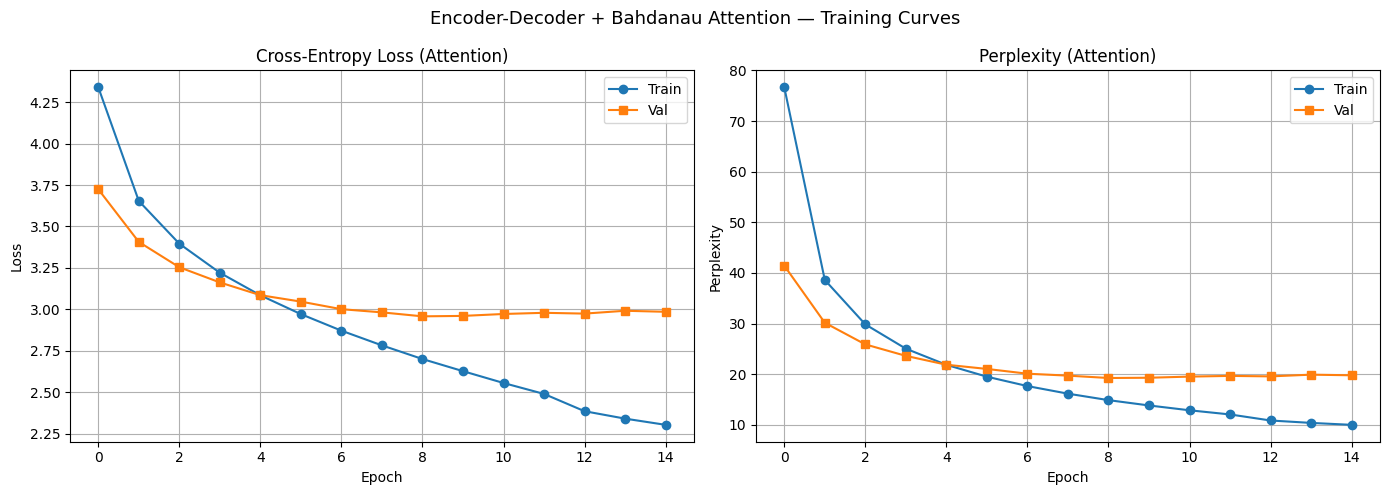

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'],   label='Val',   marker='s')
axes[0].set_title('Cross-Entropy Loss (Attention)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history['train_ppl'], label='Train', marker='o')
axes[1].plot(history['val_ppl'],   label='Val',   marker='s')
axes[1].set_title('Perplexity (Attention)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].legend(); axes[1].grid(True)

plt.suptitle('Encoder-Decoder + Bahdanau Attention — Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('attention_curves.png', dpi=150)
plt.show()

## 12. Evaluation on Test Set

In [25]:
model.load_state_dict(torch.load('best_enc_dec_attention.pth'))
model.eval()

test_loss, test_ppl = run_epoch(test_loader, train=False)
print(f'Test Loss : {test_loss:.4f}')
print(f'Test PPL  : {test_ppl:.2f}')

bleu1_list, bleu4_list = [], []
sample_df = test_df.drop_duplicates('image').head(500)

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    img = Image.open(os.path.join(IMG_DIR, row['image'])).convert('RGB')
    img_tensor = transform_val(img).unsqueeze(0).to(device)
    pred, _ = model.caption(img_tensor, vocab)
    ref  = row['caption']
    bleu1_list.append(bleu_score(ref, pred, max_n=1))
    bleu4_list.append(bleu_score(ref, pred, max_n=4))

avg_b1 = np.mean(bleu1_list)
avg_b4 = np.mean(bleu4_list)
print(f'\nAvg BLEU-1 : {avg_b1:.2f}')
print(f'Avg BLEU-4 : {avg_b4:.2f}')

metrics = {
    'model': 'EncoderDecoder_Attention',
    'test_loss': round(test_loss, 4),
    'test_ppl': round(test_ppl, 2),
    'bleu1': round(avg_b1, 2),
    'bleu4': round(avg_b4, 2),
}
with open('metrics_attention.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('\nMetrics saved.')
print(metrics)

Test Loss : 2.9847
Test PPL  : 19.78


100%|██████████| 500/500 [00:07<00:00, 66.55it/s]


Avg BLEU-1 : 23.22
Avg BLEU-4 : 1.63

Metrics saved.
{'model': 'EncoderDecoder_Attention', 'test_loss': 2.9847, 'test_ppl': 19.78, 'bleu1': np.float64(23.22), 'bleu4': np.float64(1.63)}


## 13. Comparison Table — Both Models

In [26]:
# Load metrics of without attention

print('='*60)
print('MODEL COMPARISON SUMMARY')
print('='*60)
print(f'{"Metric":<20} {"Enc-Dec (No Attn)":>20} {"Enc-Dec + Attn":>18}')
print('-'*60)
print('(Run both notebooks and compare the printed values below)')
print(f'{"Test Loss":<20} {"—":>20} {metrics["test_loss"]:>18}')
print(f'{"Test PPL":<20} {"—":>20} {metrics["test_ppl"]:>18}')
print(f'{"BLEU-1":<20} {"—":>20} {metrics["bleu1"]:>18}')
print(f'{"BLEU-4":<20} {"—":>20} {metrics["bleu4"]:>18}')
print('='*60)
print('Fill in No-Attention values from Colab 1 metrics_enc_dec.json')

MODEL COMPARISON SUMMARY
Metric                  Enc-Dec (No Attn)     Enc-Dec + Attn
------------------------------------------------------------
(Run both notebooks and compare the printed values below)
Test Loss                               —             2.9847
Test PPL                                —              19.78
BLEU-1                                  —              23.22
BLEU-4                                  —               1.63
Fill in No-Attention values from Colab 1 metrics_enc_dec.json


## 14. Attention Visualisation

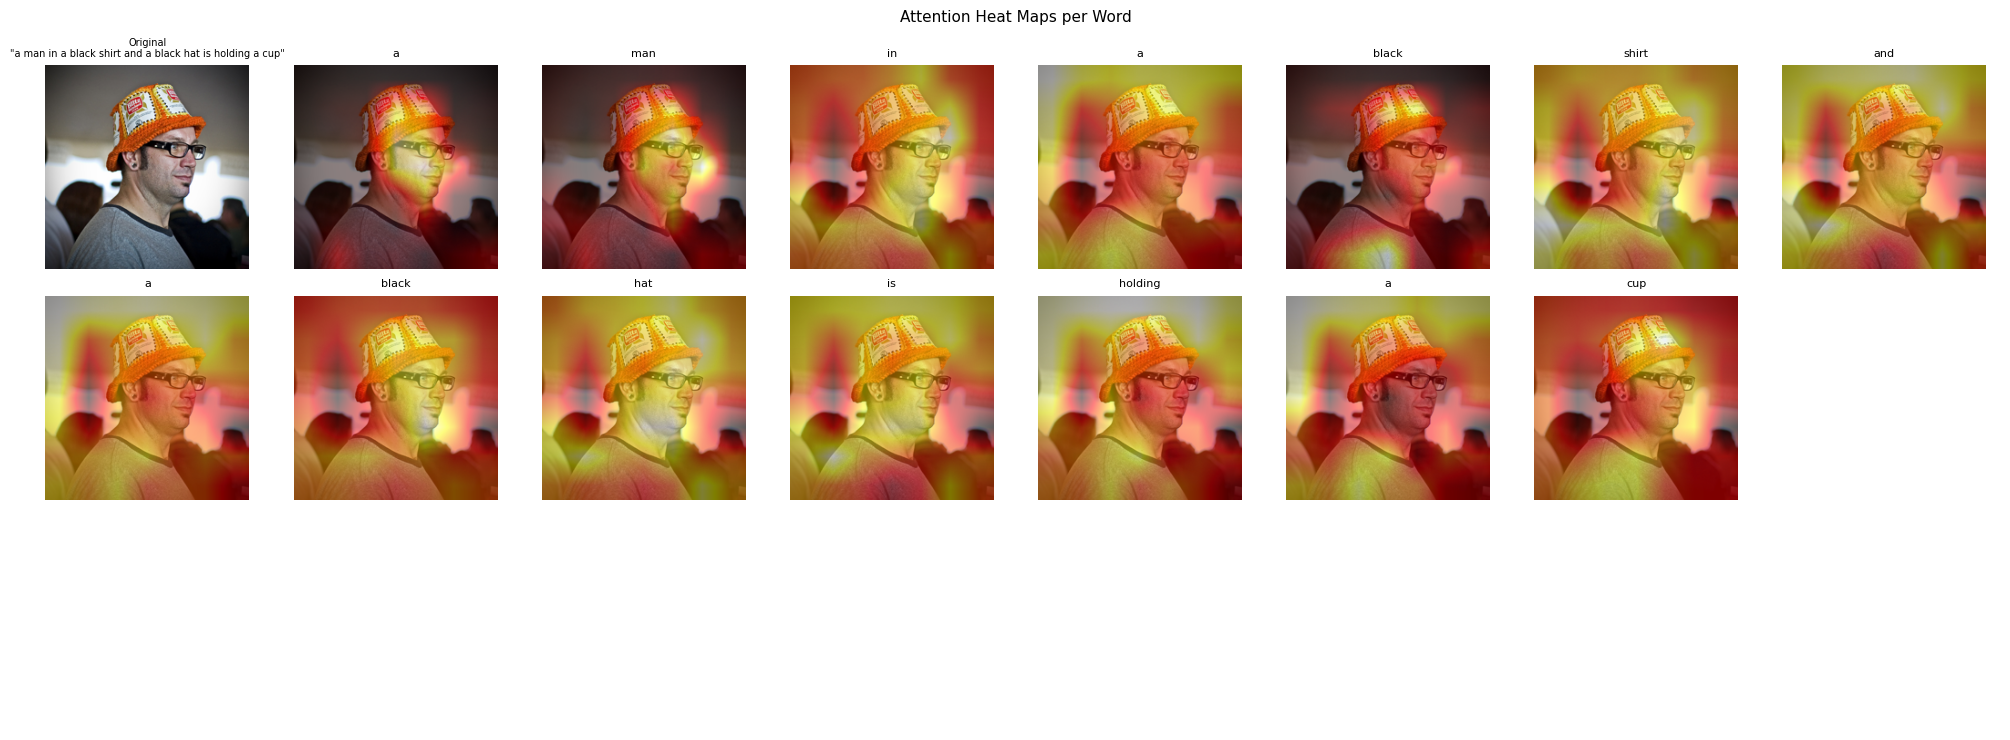

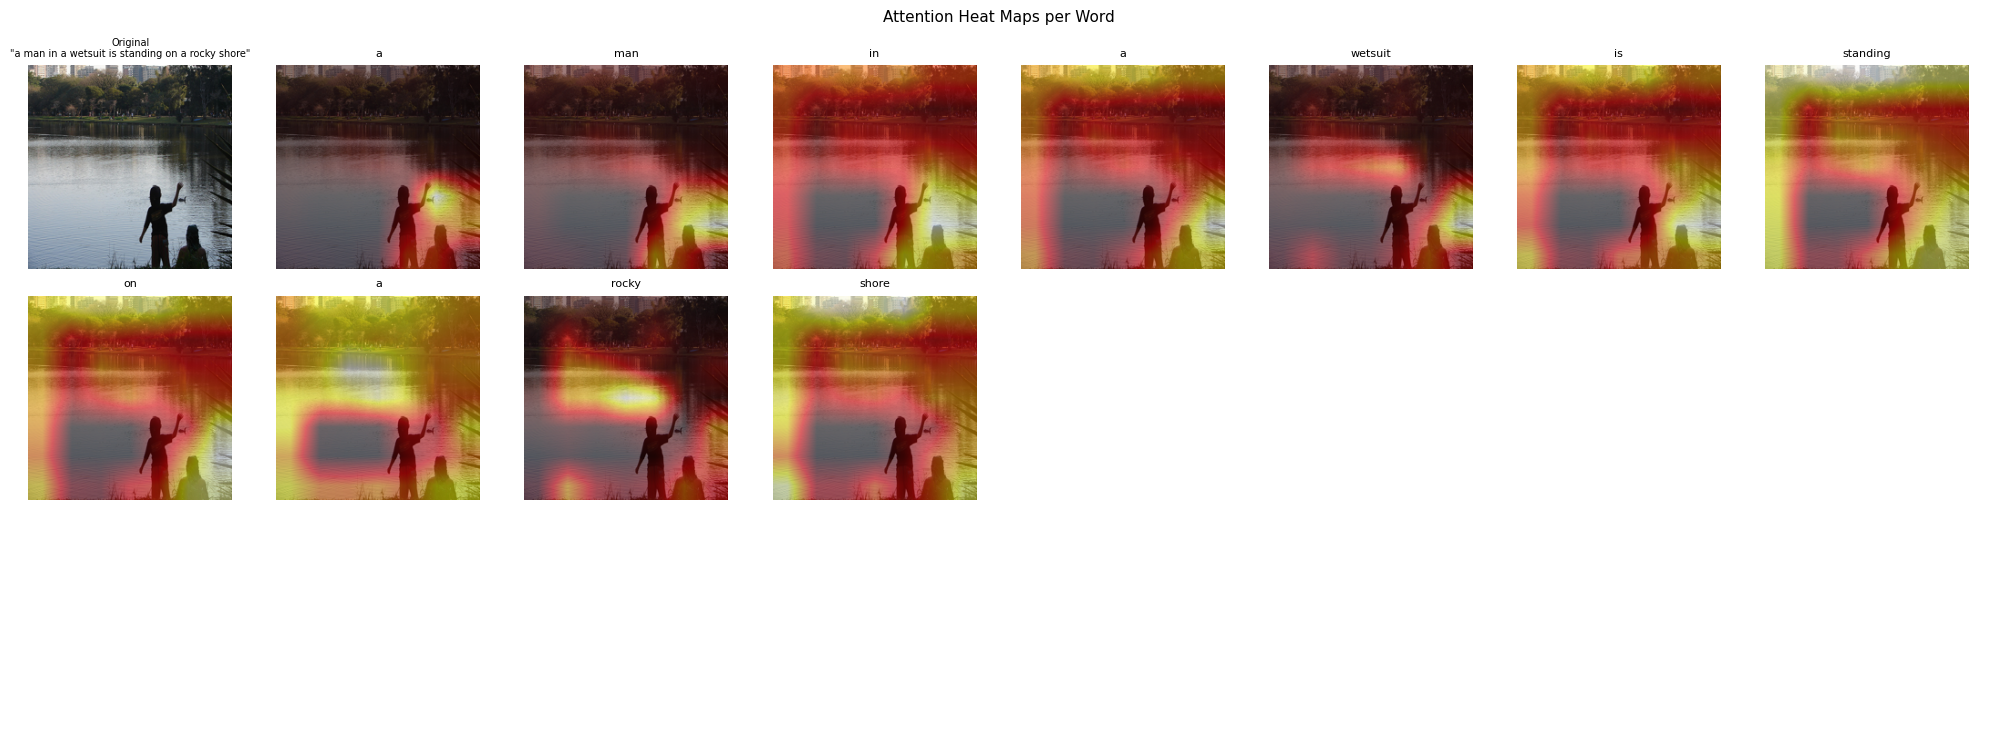

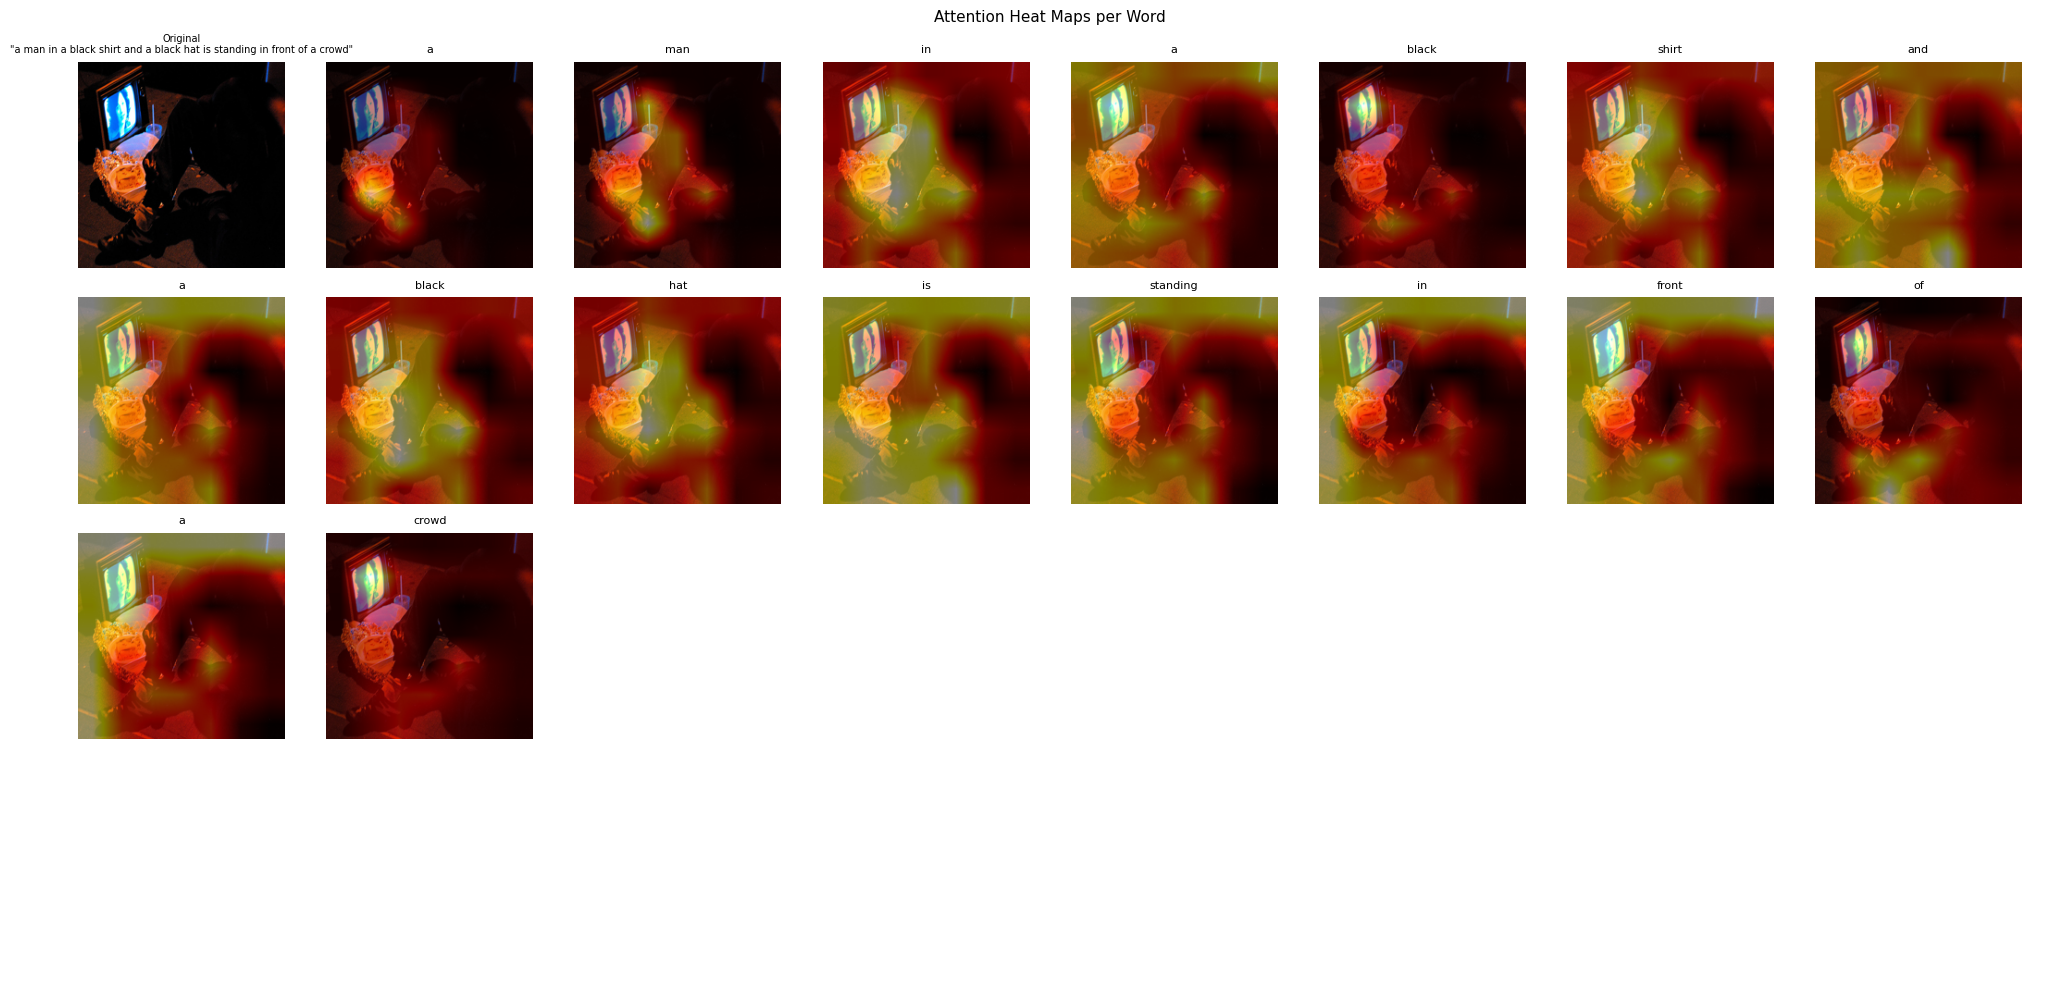

In [27]:
def visualize_attention(image_path, model, vocab, transform, save_path=None):
    model.eval()
    img_pil = Image.open(image_path).convert('RGB')
    img_tensor = transform(img_pil).unsqueeze(0).to(device)

    caption, alphas = model.caption(img_tensor, vocab)
    words = caption.split()
    alphas = [a.squeeze(0).cpu().numpy() for a in alphas[:len(words)]]

    cols = min(len(words), 8)
    rows = math.ceil(len(words) / cols) + 1
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
    axes = axes.flatten()

    # Original
    axes[0].imshow(img_pil.resize((224, 224)))
    axes[0].set_title(f'Original\n"{caption}"', fontsize=7)
    axes[0].axis('off')

    img_arr = np.array(img_pil.resize((224, 224)))
    for i, (word, alpha) in enumerate(zip(words, alphas)):
        att_map = alpha.reshape(7, 7)
        att_map = np.array(Image.fromarray(att_map).resize((224, 224), Image.BILINEAR))
        ax = axes[i+1]
        ax.imshow(img_arr)
        ax.imshow(att_map, cmap='hot', alpha=0.5)
        ax.set_title(word, fontsize=8)
        ax.axis('off')

    for j in range(len(words)+1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Attention Heat Maps per Word', fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=130)
    plt.show()


# Demo on 3 test images
sample_imgs = test_df.drop_duplicates('image').head(3)['image'].tolist()
for i, img_name in enumerate(sample_imgs):
    visualize_attention(
        os.path.join(IMG_DIR, img_name),
        model, vocab, transform_val,
        save_path=f'attention_vis_{i}.png'
    )

## 15. Visual Test — Sample Captions

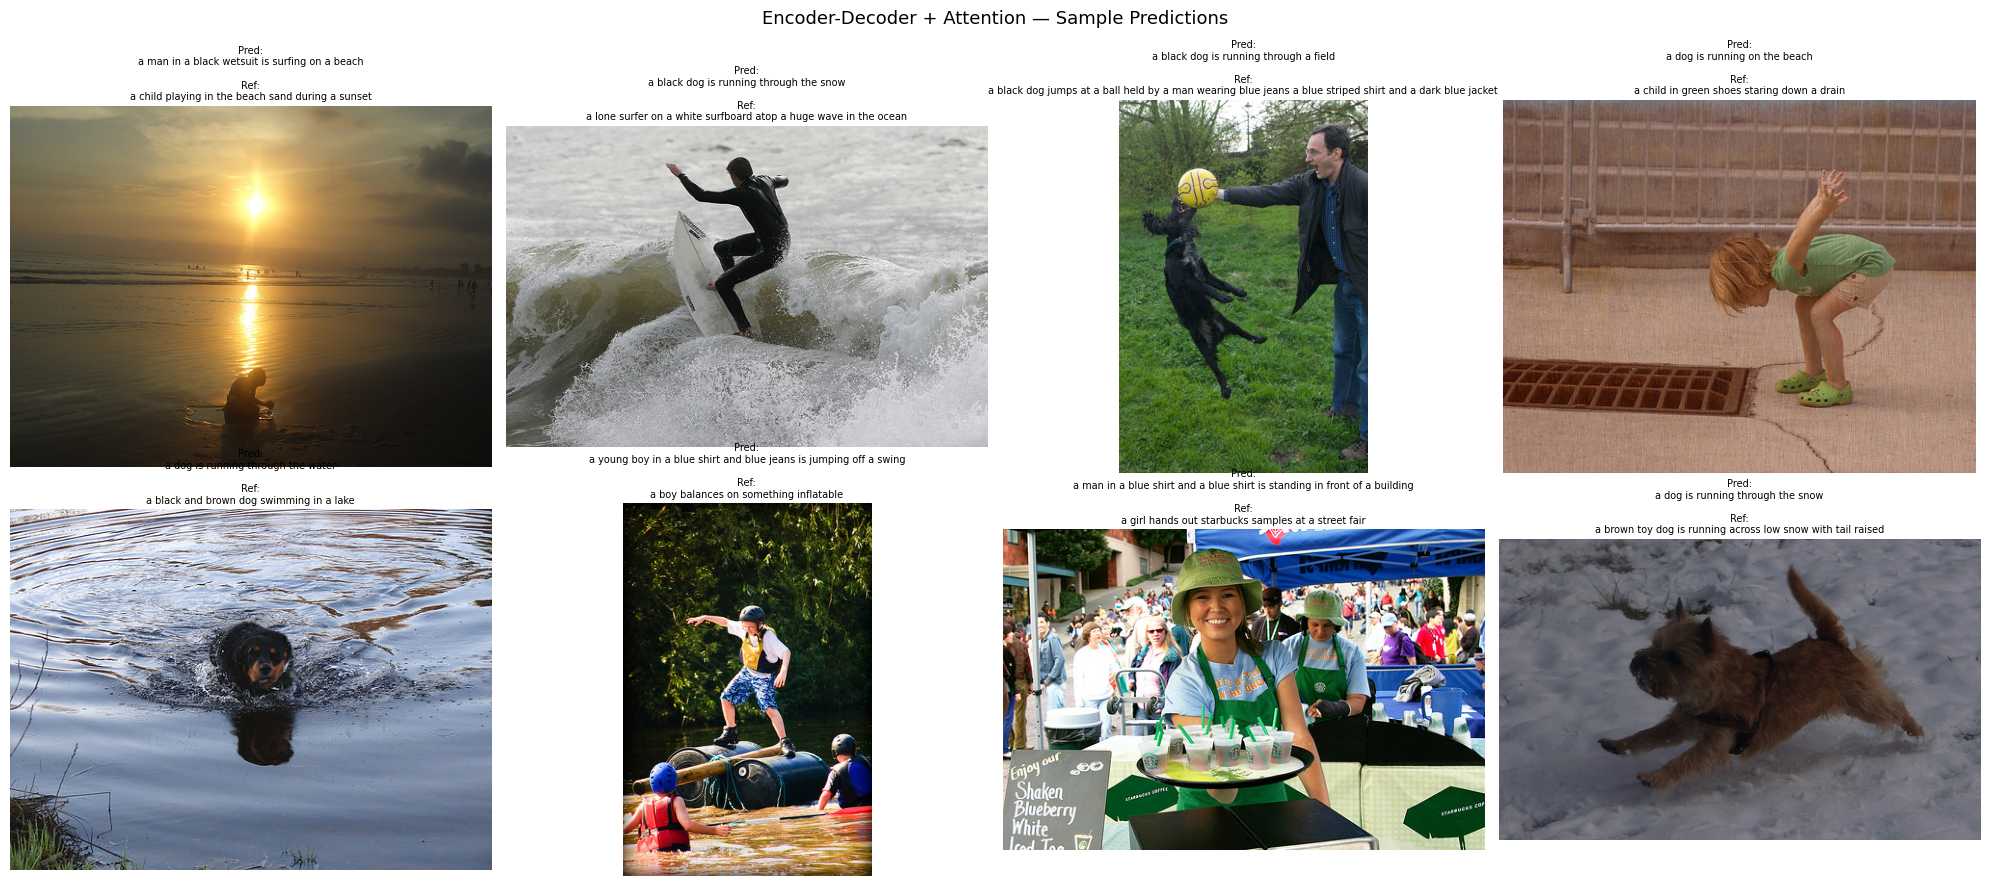

In [28]:
model.eval()
samples = test_df.drop_duplicates('image').sample(8, random_state=SEED)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for ax, (_, row) in zip(axes.flatten(), samples.iterrows()):
    img_path = os.path.join(IMG_DIR, row['image'])
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform_val(img).unsqueeze(0).to(device)
    pred, _ = model.caption(img_tensor, vocab)
    ax.imshow(img)
    ax.set_title(f'Pred:\n{pred}\n\nRef:\n{row["caption"]}',
                 fontsize=7, wrap=True)
    ax.axis('off')

plt.suptitle('Encoder-Decoder + Attention — Sample Predictions', fontsize=13)
plt.tight_layout()
plt.savefig('attention_samples.png', dpi=150)
plt.show()

## 16. Save Full Model & Download

In [29]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'vocab_word2idx': vocab.word2idx,
    'vocab_idx2word': vocab.idx2word,
    'hyperparams': {
        'embed_dim': EMBED_DIM,
        'hidden_dim': HIDDEN_DIM,
        'attention_dim': ATTENTION_DIM,
        'vocab_size': VOCAB_SIZE,
        'img_size': IMG_SIZE,
        'max_seq_len': MAX_SEQ_LEN,
        'num_pixels': NUM_PIXELS,
    },
    'history': history,
    'metrics': metrics,
}
torch.save(checkpoint, 'enc_dec_attention_full.pth')
print('Full checkpoint saved: enc_dec_attention_full.pth')

Full checkpoint saved: enc_dec_attention_full.pth


In [30]:
from google.colab import files
files.download('enc_dec_attention_full.pth')
files.download('metrics_attention.json')
files.download('attention_curves.png')
files.download('attention_samples.png')
for i in range(3):
    try:
        files.download(f'attention_vis_{i}.png')
    except:
        pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>